# 01_EDA

# 1. Introducción

Este conjunto de datos contiene información sobre una empresa de telecomunicaciones ficticia que proporcionó servicios de telefonía fija e Internet a 7043 clientes en California durante el tercer trimestre. El dataset se utiliza comúnmente para realizar análisis de retención de clientes y construir modelos predictivos que identifiquen quiénes tienen mayor probabilidad de abandonar el servicio (*churn*).


A continuación se describen las variables incluidas en el dataset:

| Variable | Descripción |
| :--- | :--- |
| **customerID** | Identificador único para cada cliente. |
| **gender** | Género del cliente (Male/Female). |
| **SeniorCitizen** | Indica si el cliente es una persona mayor (1: Sí, 0: No). |
| **Partner** | Indica si el cliente tiene pareja (Yes/No). |
| **Dependents** | Indica si el cliente tiene dependientes (Yes/No). |
| **tenure** | Número de meses que el cliente ha permanecido en la compañía. |
| **PhoneService** | Indica si el cliente tiene servicio telefónico (Yes/No). |
| **MultipleLines** | Indica si el cliente tiene múltiples líneas (Yes, No, No phone service). |
| **InternetService** | Proveedor de servicio de Internet del cliente (DSL, Fiber optic, No). |
| **OnlineSecurity** | Indica si el cliente tiene seguridad en línea (Yes, No, No internet service). |
| **OnlineBackup** | Indica si el cliente tiene respaldo en línea (Yes, No, No internet service). |
| **DeviceProtection** | Indica si el cliente tiene protección de dispositivo (Yes, No, No internet service). |
| **TechSupport** | Indica si el cliente tiene soporte técnico (Yes, No, No internet service). |
| **StreamingTV** | Indica si el cliente utiliza el servicio de streaming de TV (Yes, No, No internet service). |
| **StreamingMovies** | Indica si el cliente utiliza el servicio de streaming de películas (Yes, No, No internet service). |
| **Contract** | El tipo de contrato del cliente (Month-to-month, One year, Two year). |
| **PaperlessBilling** | Indica si el cliente utiliza factura sin papel (Yes/No). |
| **PaymentMethod** | Método de pago del cliente (Electronic check, Mailed check, Bank transfer, Credit card). |
| **MonthlyCharges** | El monto cargado al cliente mensualmente. |
| **TotalCharges** | El monto total cargado al cliente hasta la fecha. |
| **Churn** | Variable objetivo; indica si el cliente canceló el servicio (Yes/No). |

# 2. Carga de paquetes y datos

In [1]:
from pathlib import Path
import re
import sys
import os

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import numpy as np

# Calculamos la raíz del proyecto (un nivel arriba de /notebooks)
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

# Convertimos a objeto Path para manipular rutas de forma limpia
ROOT_DIR = Path(root_path)


import src.utils.utils as utils

# Autoreload para que detecte cambios en utils.py sin reiniciar el kernel
%load_ext autoreload
%autoreload 2


DATA_PATH = ROOT_DIR / "data" / "raw" / "telco_customer_churn.csv"
REPORTS_DIR = ROOT_DIR / "reports" / "figures"

# Crear carpetas si no existen
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Caragmos el dataset
if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontró el archivo en: {DATA_PATH}")

df = pl.read_csv(
    DATA_PATH,
    infer_schema_length=1000, # Polars por defecto escanea pocas filas. Le decimos que
                              # lea 1000 para ver de qué tipo es cada variable
    null_values=["", " ", "NA", "N/A"] # Normalizamos los missing values
)



In [2]:
# Normalizamos los nombres de columnas
df = df.rename({col: utils.to_snake_case(col) for col in df.columns}) # Toma cada nombre original (col que hemos sacado con df.columns)
                                                                      # y le asigna el nuevo nombre generado por la función.
                                                                      # por ejemplo: 'CustomerID': 'customer_id'

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


customer_i_d,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_t_v,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
str,str,i64,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str
"""7590-VHVEG""","""Female""",0,"""Yes""","""No""",1,"""No""","""No phone service""","""DSL""","""No""","""Yes""","""No""","""No""","""No""","""No""","""Month-to-month""","""Yes""","""Electronic check""",29.85,29.85,"""No"""
"""5575-GNVDE""","""Male""",0,"""No""","""No""",34,"""Yes""","""No""","""DSL""","""Yes""","""No""","""Yes""","""No""","""No""","""No""","""One year""","""No""","""Mailed check""",56.95,1889.5,"""No"""
"""3668-QPYBK""","""Male""",0,"""No""","""No""",2,"""Yes""","""No""","""DSL""","""Yes""","""Yes""","""No""","""No""","""No""","""No""","""Month-to-month""","""Yes""","""Mailed check""",53.85,108.15,"""Yes"""
"""7795-CFOCW""","""Male""",0,"""No""","""No""",45,"""No""","""No phone service""","""DSL""","""Yes""","""No""","""Yes""","""Yes""","""No""","""No""","""One year""","""No""","""Bank transfer (automatic)""",42.3,1840.75,"""No"""
"""9237-HQITU""","""Female""",0,"""No""","""No""",2,"""Yes""","""No""","""Fiber optic""","""No""","""No""","""No""","""No""","""No""","""No""","""Month-to-month""","""Yes""","""Electronic check""",70.7,151.65,"""Yes"""


# 3. Rápida revisión de la calidad de los datos.

In [3]:
# Información general
print("Columnas:", df.columns)
print("Filas:", df.height)
print("Columnas totales:", df.width)

# Duplicados
n_duplicates = df.is_duplicated().sum()
print("Filas duplicadas:", n_duplicates)

# Tipos de datos
print("\nTipos de columnas:")
print(df.schema)

# Pasamos a pandas para un análisis rápido de nulos
pdf = df.to_pandas()

utils.resumen_nulos_ceros(pdf)

Columnas: ['customer_i_d', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_t_v', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'churn']
Filas: 7043
Columnas totales: 21
Filas duplicadas: 0

Tipos de columnas:
Schema([('customer_i_d', String), ('gender', String), ('senior_citizen', Int64), ('partner', String), ('dependents', String), ('tenure', Int64), ('phone_service', String), ('multiple_lines', String), ('internet_service', String), ('online_security', String), ('online_backup', String), ('device_protection', String), ('tech_support', String), ('streaming_t_v', String), ('streaming_movies', String), ('contract', String), ('paperless_billing', String), ('payment_method', String), ('monthly_charges', Float64), ('total_charges', Float64), ('churn', String)])


,variable_type,variable,n_missing,n_missing_perc,n_zeros,n_zeros_perc
19,float64,total_charges,11,0.156000,0,0.000000
18,float64,monthly_charges,0,0.000000,0,0.000000
2,int64,senior_citizen,0,0.000000,5901,83.785000
5,int64,tenure,0,0.000000,11,0.156000
0,object,customer_i_d,0,0.000000,0,0.000000
1,object,gender,0,0.000000,0,0.000000
3,object,partner,0,0.000000,0,0.000000
4,object,dependents,0,0.000000,0,0.000000
6,object,phone_service,0,0.000000,0,0.000000
7,object,multiple_lines,0,0.000000,0,0.000000


Cambiamos el tipado de las variables:

In [4]:
vars_num = ["tenure", "monthly_charges", "total_charges"]
var_id = ["customer_i_d"]

cols_cat = [col for col in pdf.columns if col not in vars_num + var_id]

pdf[cols_cat] = pdf[cols_cat].astype('category')

for col in vars_num:
    pdf[col] = pd.to_numeric(pdf[col], errors='coerce')

pdf[var_id] = pdf[var_id].astype('string')

Veerificamos que el proceso ha funcionado correctamente:

In [5]:
utils.resumen_nulos_ceros(pdf)

,variable_type,variable,n_missing,n_missing_perc,n_zeros,n_zeros_perc
1,category,gender,0,0.000000,0,0.000000
2,category,senior_citizen,0,0.000000,0,0.000000
3,category,partner,0,0.000000,0,0.000000
4,category,dependents,0,0.000000,0,0.000000
6,category,phone_service,0,0.000000,0,0.000000
7,category,multiple_lines,0,0.000000,0,0.000000
8,category,internet_service,0,0.000000,0,0.000000
9,category,online_security,0,0.000000,0,0.000000
10,category,online_backup,0,0.000000,0,0.000000
11,category,device_protection,0,0.000000,0,0.000000


# 4. Análisis univariante y bivariante

## 4.1. Variables numéricas

En primer lugar, vamos a ver la distribución de las variables numéricas:

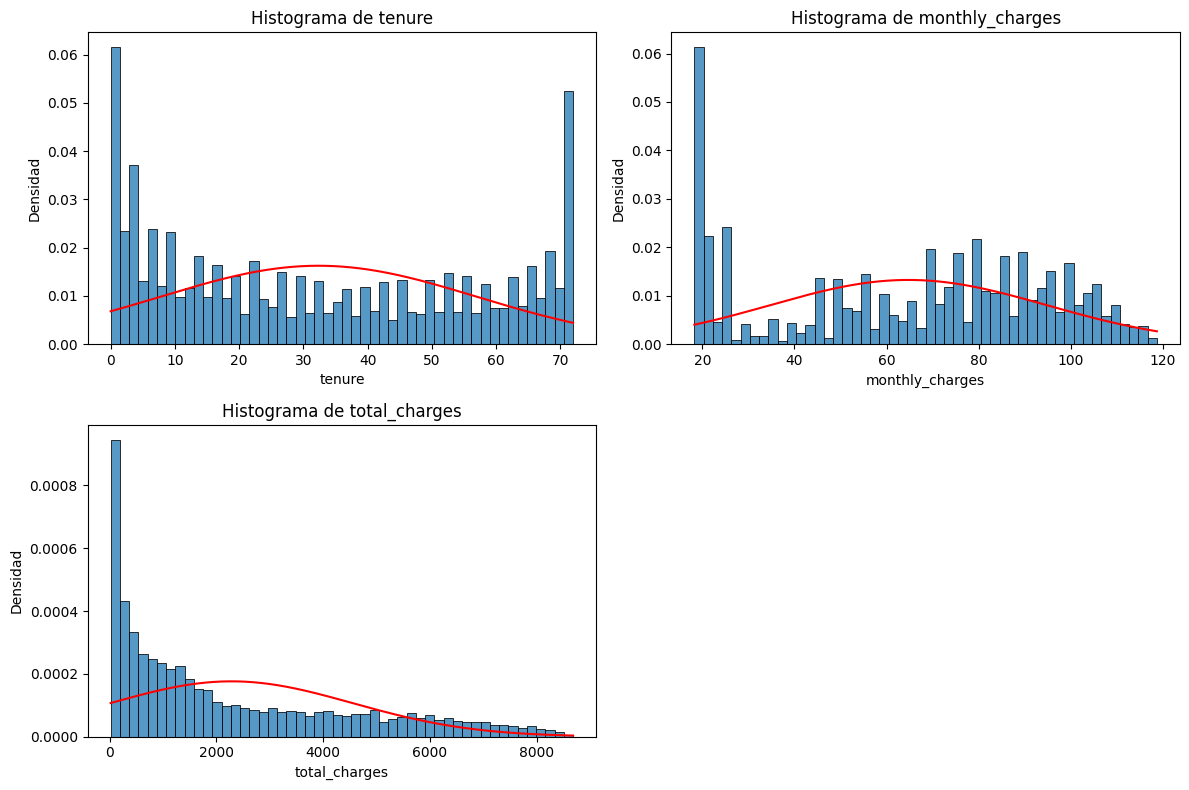

In [6]:
# Seleccionamos solo las columnas numéricas 
cols_numericas = pdf.select_dtypes(include=[np.number]).columns

n_cols = 2
n_rows = (len(cols_numericas) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4))
axes = axes.flatten() # Aplanamos para iterar fácilmente

for i, col in enumerate(cols_numericas):
    utils.histogram_plot(pdf, col, ax=axes[i])

# Eliminamos los ejes sobrantes 
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 4.2. Variable Target

In [7]:
target_dist = (
    pdf["churn"]
    .value_counts(dropna = False) # contamos cuántos calores hay, incluyendo los posibles NA
    .rename_axis("churn") # le damos nombre a la serie resultante
    .reset_index(name = "count") # convertimos la serire a DF (conlumnas churn y count)
)
# Creamos la columna pct:
target_dist["pct"] = (target_dist["count"] / target_dist["count"].sum() * 100).round(2)
display(target_dist)

,churn,count,pct
0,No,5174,73.46
1,Yes,1869,26.54


Geaficamos:

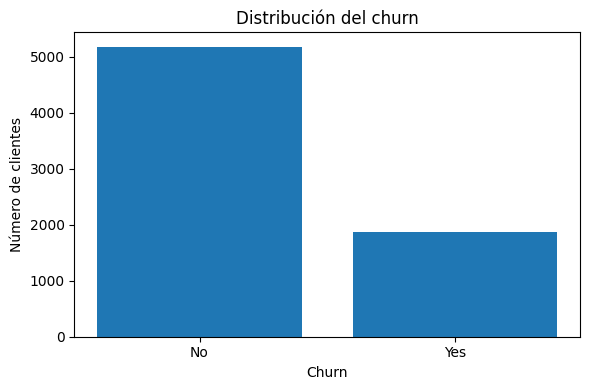

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(target_dist["churn"].astype(str), target_dist["count"])
ax.set_title("Distribución del churn")
ax.set_xlabel("Churn")
ax.set_ylabel("Número de clientes")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "target_distribution.png", dpi=150)
plt.show()

Vemos claramento que el dataset está desbalanceado: hay más clientes que permanecen de los que se van.

## 4.3. Variables categóricas

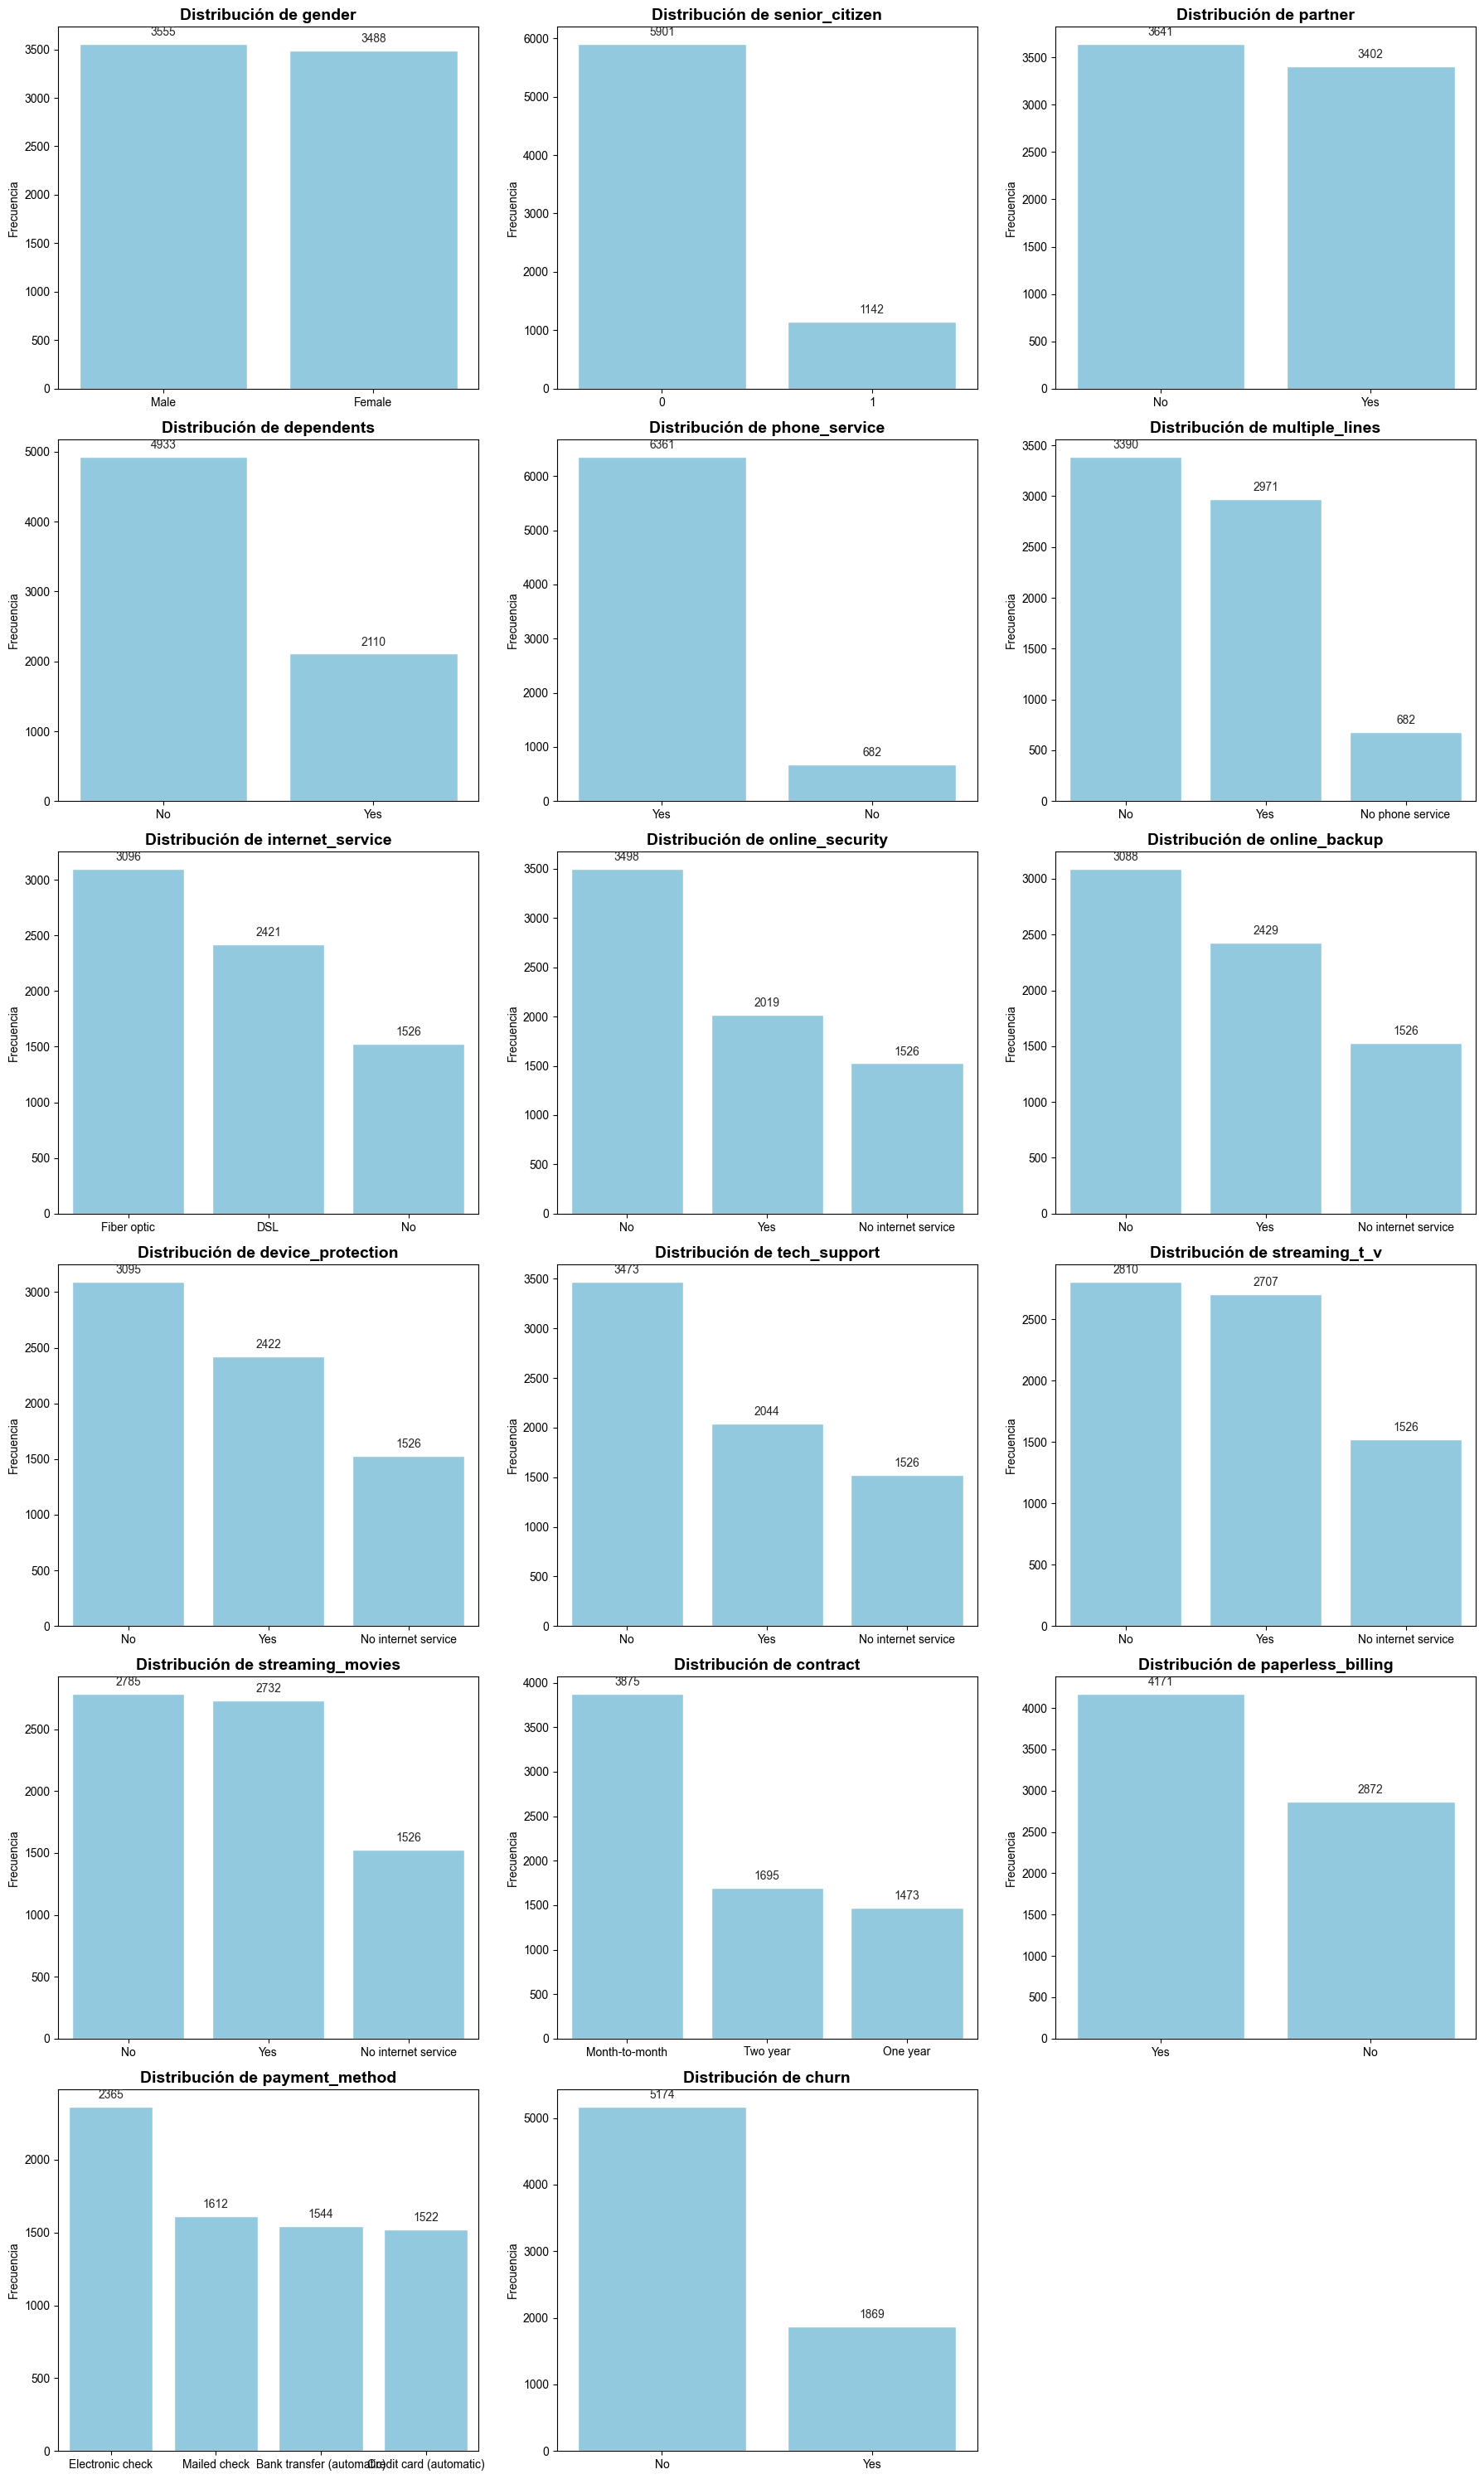

In [9]:
utils.plot_categoricas(pdf)

## 4.4. Churn por tipo de contrato

Realizamos estos resúmenes con **DuckDB usando SQL**:

In [10]:
con = duckdb.connect() 
con.register("churn", pdf)  

contract_churn = con.execute("""
    SELECT
        contract,
        churn,
        COUNT(*) AS n
    FROM churn
    GROUP BY contract, churn 
    ORDER BY contract, churn
""").df()


# Ahora pivotamos la tabla
pivot_contract = contract_churn.pivot(index="contract", columns="churn", values="n").fillna(0)
pivot_contract["churn_rate_pct"] = (pivot_contract.get("Yes", 0) / pivot_contract.sum(axis=1) * 100).round(2)

display(pivot_contract.sort_values("churn_rate_pct", ascending=False))

churn,No,Yes,churn_rate_pct
contract,,,
Month-to-month,2220,1655,42.71
One year,1307,166,11.27
Two year,1647,48,2.83


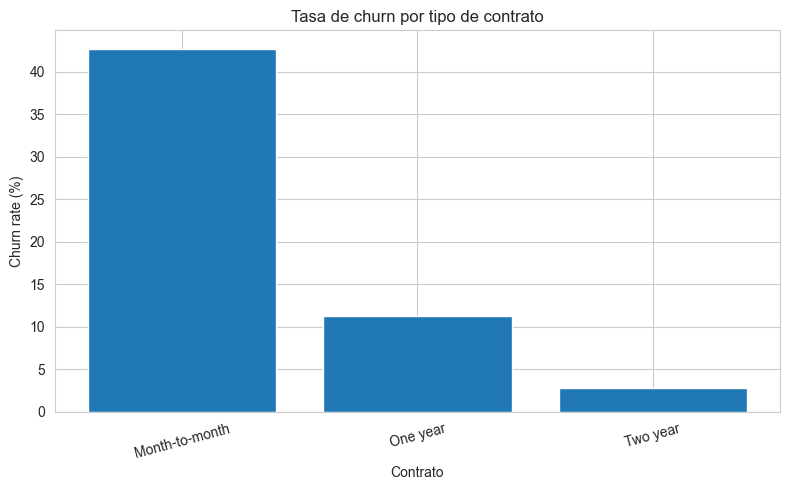

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

order = pivot_contract["churn_rate_pct"].sort_values(ascending=False).index
ax.bar(order.astype(str), pivot_contract.loc[order, "churn_rate_pct"])

ax.set_title("Tasa de churn por tipo de contrato")
ax.set_xlabel("Contrato")
ax.set_ylabel("Churn rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "churn_by_contract.png", dpi=150)
plt.show()

Observamos que, a mayor permanencia, menor churn.

## 4.5. Distribución de la permanencia y los cargos mensuales

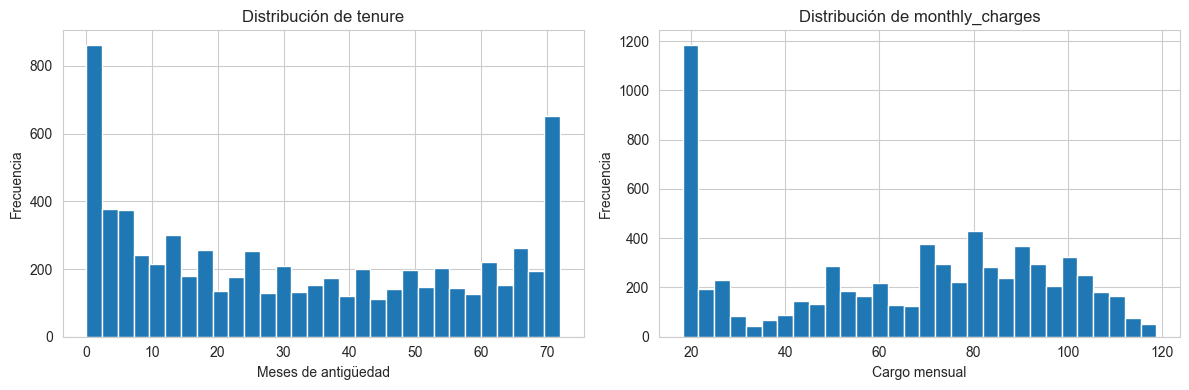

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Tenure
axes[0].hist(pdf["tenure"], bins=30)
axes[0].set_title("Distribución de tenure")
axes[0].set_xlabel("Meses de antigüedad")
axes[0].set_ylabel("Frecuencia")

# Monthly charges
axes[1].hist(pdf["monthly_charges"].dropna(), bins=30)
axes[1].set_title("Distribución de monthly_charges")
axes[1].set_xlabel("Cargo mensual")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "numeric_distributions.png", dpi=150)
plt.show()

Se observa que ninguna de las distribuciones es gaussiana.

En cuanto a la permanencia, vemos que hay muchos clientes nuevos, aunque también hay bastantes que tienen larga permanencia.

En cuanto a los cargos mensuales, la mayoría son lo más baratos posibles.

## 4.6. Comparación de permanencia entre churn y no churn

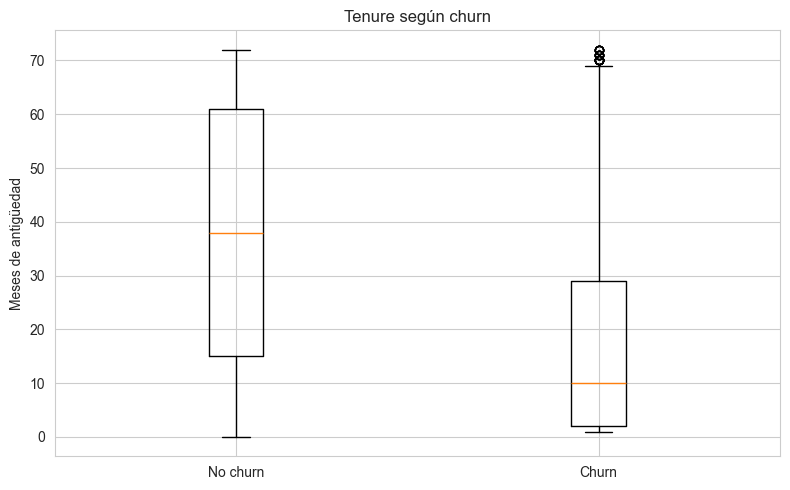

In [13]:
churn_yes = pdf.loc[pdf["churn"] == "Yes", "tenure"].dropna()
churn_no = pdf.loc[pdf["churn"] == "No", "tenure"].dropna()

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([churn_no, churn_yes], tick_labels=["No churn", "Churn"])
ax.set_title("Tenure según churn")
ax.set_ylabel("Meses de antigüedad")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "tenure_by_churn.png", dpi=150)
plt.show()

Observamos que la antigüedad es un factor que determina los churns: Los clientes que permanecen (no churn) tienen una mediana de antigüedad cercana a los 38-40 meses, mientras que los que se van (Churn) suelen hacerlo alrededor de los 10 meses.

El 75% de los clientes que abandonan (churn) tienen menos de 30 meses de antigüedad. Esto sugiere que los primeros dos años son cruciales para asegurar la retención.

## 4.7. Gráficos estratificados

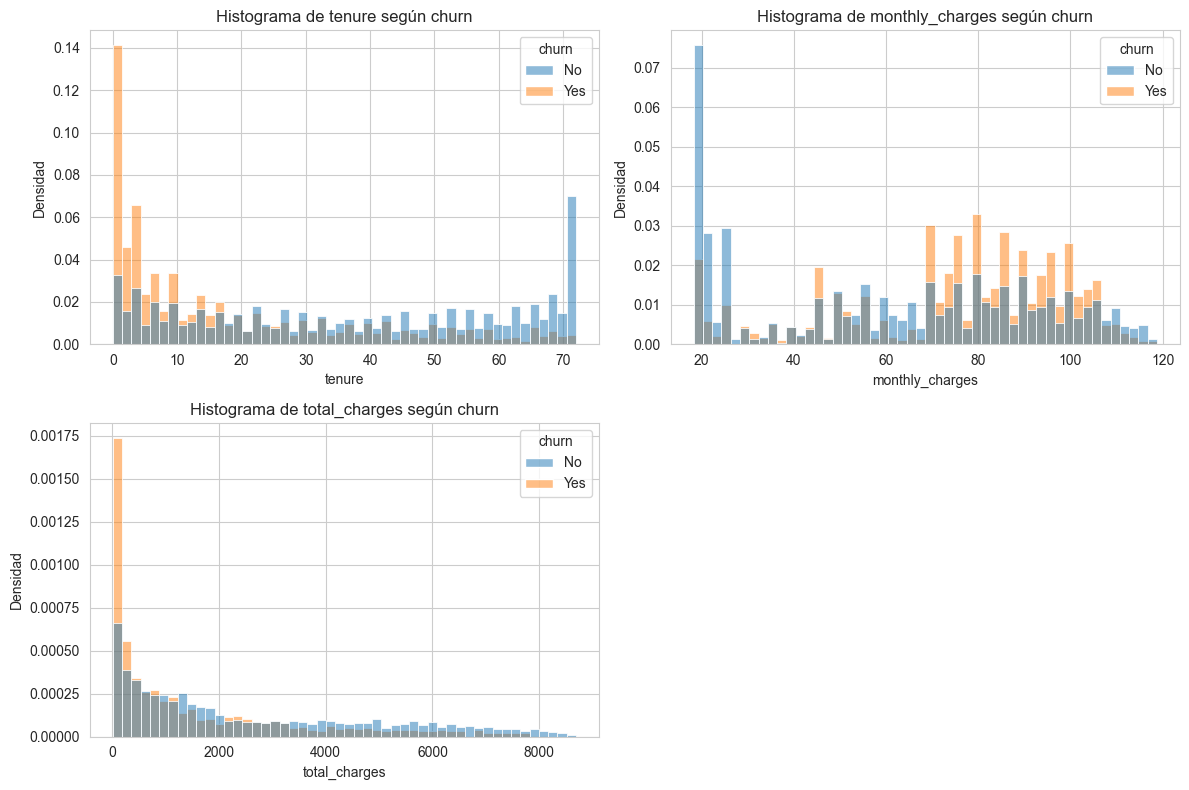

In [14]:
# Seleccionamos solo las columnas numéricas 
cols_numericas = pdf.select_dtypes(include=[np.number]).columns

n_cols = 2
n_rows = (len(cols_numericas) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4))
axes = axes.flatten() # Aplanamos para iterar fácilmente

for i, col in enumerate(cols_numericas):
    utils.histogram_var_target_plot(pdf, col, ax=axes[i])

# Eliminamos los ejes sobrantes 
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

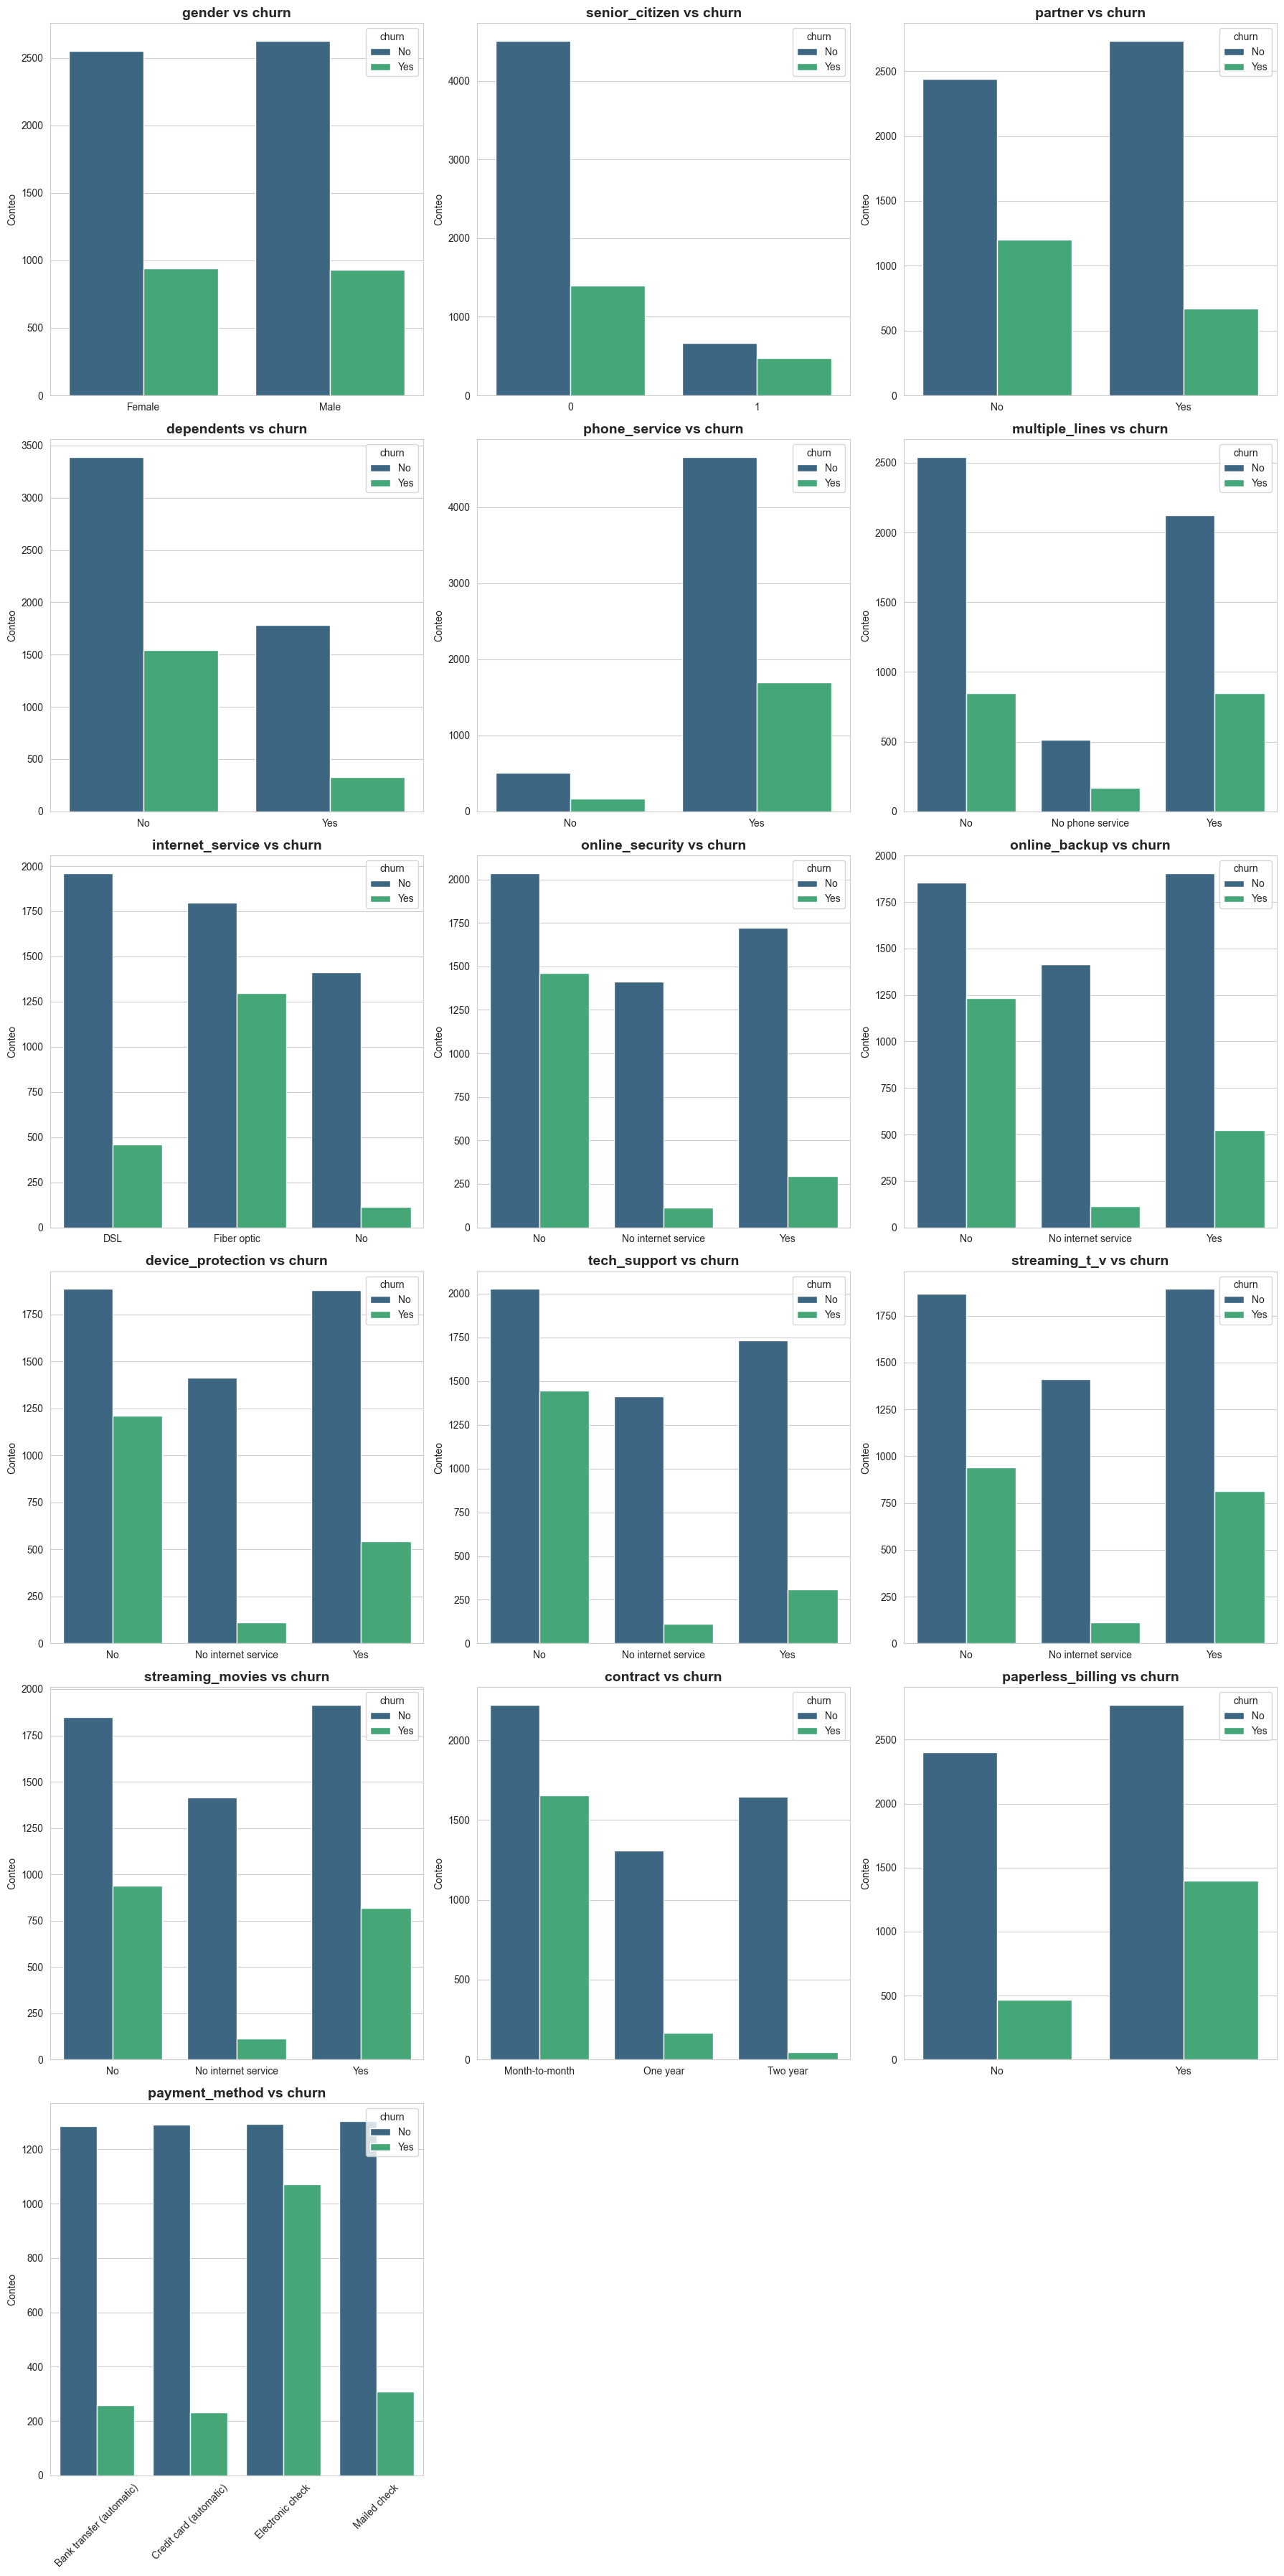

In [15]:
utils.plot_cat_vs_target(pdf, target = 'churn')

Guardamos el dataset con los cambios mínimos que hemos hecho, en formato parquet para mantener el tipado de las variables:


In [16]:
pdf.to_parquet('data/processed/telco_customers_churn_EDA.parquet', index=False, engine='pyarrow')